In [1]:
import sys
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib as mpl
import sympy as sp
import graphviz as gv
import pickle
import gzip
import subprocess
import warnings

# Suprimir los 'FutureWarnings' de numpy/tensorflow (son solo advertencias)
warnings.simplefilter(action='ignore', category=FutureWarning)

print("--- VERIFICACIÓN DEL ENTORNO 'eql_clean' ---")
print(f"Versión de Python: {sys.version.split(' ')[0]} (desde {os.path.basename(sys.executable)})")
print(f"TensorFlow (TF):    {tf.__version__}")
print(f"Numpy:            {np.__version__}")
print(f"Pandas:           {pd.__version__}")
print(f"Matplotlib:       {mpl.__version__}")
print(f"Sympy:            {sp.__version__}")
print(f"Graphviz (Python):{gv.__version__}")

# --- Prueba de Fuego ---
# Esto es lo que falló la última vez (AttributeError)
try:
    import tensorflow.estimator
    print("\n[ÉXITO] 'tensorflow.estimator' importado correctamente.")
except ImportError as e:
    print(f"\n[FALLO] 'tensorflow.estimator' no se pudo importar: {e}")

print("---------------------------------------------")
print("Si todo es correcto, ejecuta la Celda 2 y la Celda 3.")

--- VERIFICACIÓN DEL ENTORNO 'eql_clean' ---
Versión de Python: 3.7.12 (desde python.exe)
TensorFlow (TF):    1.15.0
Numpy:            1.16.6
Pandas:           1.1.5
Matplotlib:       3.3.4
Sympy:            1.6.2
Graphviz (Python):0.20.1

[ÉXITO] 'tensorflow.estimator' importado correctamente.
---------------------------------------------
Si todo es correcto, ejecuta la Celda 2 y la Celda 3.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import sympy as sp
import os
import shutil
from IPython.display import Image, display
import json
import pickle
import gzip
import subprocess
import warnings

# Suprimir los 'FutureWarnings' de numpy/tensorflow
warnings.simplefilter(action='ignore', category=FutureWarning)

# Importaciones de sklearn y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

print("Importaciones para EQL-Div cargadas.")

# --- Funciones de Datos y Evaluación ---

def generate_nguyen_data(func_id, n_samples=512):
    """
    Genera dataset sintético.
    (Corregido para numpy 1.16 - sin default_rng)
    """
    # np.random.seed() se llama en la Celda 3
    X = None
    data_range = [-1, 1]
    
    if func_id == 7:
        # N-7 usa el rango [0, 2]
        f = lambda x: np.log(x + 1) + np.log(x**2 + 1)
        dim = 1
        data_range = [0, 2] # Rango de datos corregido
    elif func_id == 8:
        # N-8 usa el rango [0, 4]
        f = lambda x: np.sqrt(x)
        dim = 1
        data_range = [0, 4] # Rango de datos corregido
    else:
        raise ValueError("Este notebook solo está configurado para func_id 7 y 8.")

    # Usamos la API "antigua" (compatible con numpy 1.16)
    X = np.random.uniform(data_range[0], data_range[1], size=(n_samples, dim))

    if dim == 1:
        y = f(X[:, 0])
        
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32), dim


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Calcula NRMSE y R² en train/test para el 'DummyModel'.
    """
    y_pred_train = model.predict(X_train) 
    y_pred_test = model.predict(X_test)

    y_pred_train = y_pred_train.reshape(-1)
    y_pred_test = y_pred_test.reshape(-1)
    y_train_flat = y_train.reshape(-1)
    y_test_flat = y_test.reshape(-1)

    def nrmse(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        denom = np.max(y_true) - np.min(y_true)
        return rmse / denom if denom != 0 else rmse

    metrics = {
        "NRMSE_train": nrmse(y_train_flat, y_pred_train),
        "NRMSE_test": nrmse(y_test_flat, y_pred_test),
        "R2_train": r2_score(y_train_flat, y_pred_train),
        "R2_test": r2_score(y_test_flat, y_pred_test),
    }
    return metrics


def plot_nguyen_fit(func_id, model, metrics=None, model_name="EQL-Div", n_points=400):
    """
    Grafica la función real y la predicha por el modelo EQL.
    """
    dim = 1
    r2_val = metrics["R2_test"] if metrics else 0.0

    if dim == 1:
        if func_id == 7: x_range = [0, 2]
        elif func_id == 8: x_range = [0, 4]
        else: x_range = [-2, 2]

        x = np.linspace(x_range[0], x_range[1], n_points).astype(np.float32)
        
        if func_id == 7: f_true = np.log(x + 1) + np.log(x**2 + 1)
        elif func_id == 8: f_true = np.sqrt(x)
        else: return

        X_plot = x.reshape(-1, 1)
        f_pred = model.predict(X_plot).flatten() 

        plt.figure(figsize=(8,4))
        plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
        plt.plot(x, f_pred, '--', label=f"Predicha ({model_name})", linewidth=2, color='C1')
        plt.xlabel("x", fontsize=12)
        plt.ylabel("y", fontsize=12)
        plt.title(f"Nguyen-{func_id} ({model_name}) | R²_test = {r2_val:.3f}",
                  fontsize=14, weight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Ploteo 2D para Nguyen-{func_id} no implementado.")

# --- Clase "Falsa" para EQL ---
class EQLDummyModel:
    def __init__(self, formula_func):
        self.formula = formula_func
    
    def predict(self, X):
        return self.formula(X[:, 0])

print("Funciones auxiliares de EQL cargadas.")

Importaciones para EQL-Div cargadas.
Funciones auxiliares de EQL cargadas.


In [19]:
# --- SIMULACIÓN EQL-Div (NGUYEN 7 y 8) ---
# Basado en el README (1).md

SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

if not os.path.exists(EQL_PATH):
    print(f"ERROR: No se encontró la carpeta EQL_Tensorflow en la ruta absoluta:")
    print(f"{EQL_PATH}")
    print("Por favor, verifica que la carpeta existe en esa ubicación.")
else:
    for func_id in [7, 8]:
        print("\n" + "="*40)
        print(f"INICIANDO SIMULACIÓN (EQL-Div) NGUYEN-{func_id}")
        print("="*40)
        
        # Usamos la semilla "antigua" de numpy 1.16
        np.random.seed(SEED) 
        
        # 1. Preparar Datos y Guardarlos
        X, y, dim = generate_nguyen_data(func_id, n_samples=512)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
        
        data_path = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_path):
            os.makedirs(data_path)
            
        train_file_path = os.path.join(data_path, f"N{func_id}_train")
        test_file_path = os.path.join(data_path, f"N{func_id}_test")
        
        print(f"Guardando {train_file_path} como gzipped pickle...")
        with gzip.open(train_file_path, "wb") as f:
            pickle.dump((X_train, y_train), f)
            
        with gzip.open(test_file_path, "wb") as f:
            pickle.dump((X_test, y_test), f)
        
        print(f"Datos para N-{func_id} guardados.")

        # 2. Ejecutar EQL train.py
        results_path = f"results/EQL_N{func_id}"
        
        full_results_path = os.path.join(EQL_PATH, results_path)
        if os.path.exists(full_results_path):
            shutil.rmtree(full_results_path)

        # Configuración para el script
        config_dict = {
            "train_val_file": f"data/N{func_id}_train", 
            "test_file": f"data/N{func_id}_test", 
            "results_path": results_path
        }
        
        config_str = json.dumps(config_dict)
        
        print(f"Ejecutando EQL... (Esto puede tardar varios minutos)")
        print(f"Comando: python train.py \"{config_str}\"")
        t_start = time.time()
        
        cmd_list = ["python", "train.py", config_str]
        
        try:
            # Usamos capture_output=True y text=True para capturar el error si falla
            # (encoding='utf-8' es importante para Windows)
            result = subprocess.run(cmd_list, cwd=EQL_PATH, check=True, 
                                    capture_output=True, text=True, encoding='utf-8')
            
            # Imprimir la salida estándar (ej. 'Train episode...')
            print(result.stdout) 
            
            t_end = time.time()
            print(f"Entrenamiento EQL (subprocess) completado en {t_end - t_start:.2f} segundos.")

        except subprocess.CalledProcessError as e:
            t_end = time.time()
            print(f"¡ERROR DURANTE LA EJECUCIÓN DE EQL! (Duración: {t_end - t_start:.2f}s)")
            print(f"El script train.py falló con el código de salida: {e.returncode}")
            
            # Imprimir el error real (stderr) que causó el 'exit code 1'
            print("\n--- STDOUT (Salida Estándar) ---")
            print(e.stdout)
            print("\n--- STDERR (Error Estándar) ---")
            print(e.stderr) # <-- ESTO NOS DARÁ EL TRACEBACK
            continue 

        # 3. Mostrar la Fórmula (el PNG)
        formula_png_path = os.path.join(full_results_path, "latex0.png")
        formula_graph_path = os.path.join(full_results_path, "graph0_y1.png")
        
        if os.path.exists(formula_png_path):
            print("\n--- Fórmula EQL (desde LaTeX PNG) ---")
            display(Image(filename=formula_png_path))
        elif os.path.exists(formula_graph_path):
            print("\n--- Fórmula EQL (desde Graphviz PNG, LaTeX falló) ---")
            display(Image(filename=formula_graph_path))
        else:
            print(f"ADVERTENCIA: No se encontró ningún archivo PNG de resultados en {full_results_path}")
            continue

        # 4. Transcripción Manual y Ploteo
        # (¡RECUERDA EDITAR ESTO BASÁNDOTE EN EL PNG!)
        
        if func_id == 7:
            # N-7: log(x + 1) + log(x^2 + 1)
            def eql_formula(x):
                # (¡¡TRANSCRIBE LA FÓRMULA DEL PNG AQUÍ!!)
                return np.log(x + 1) + np.log(x**2 + 1)
            
        elif func_id == 8:
            # N-8: sqrt(x)
            def eql_formula(x):
                # (¡¡TRANSCRIBE LA FÓRMULA DEL PNG AQUÍ!!)
                return np.sqrt(x)

        # 5. Crear "Dummy Model" y Graficar
        eql_model = EQLDummyModel(eql_formula)
        
        metrics = evaluate_model(eql_model, X_train, y_train.ravel(), X_test, y_test.ravel())

        print(f"\n--- Resultados EQL-Div Nguyen-{func_id} ---")
        print(f"Métricas (basadas en fórmula transcrita): {metrics}")

        plot_nguyen_fit(func_id, eql_model, metrics, model_name="EQL-Div")

    print("\n" + "="*40)
    print("TODAS LAS SIMULACIONES EQL COMPLETADAS")
    print("="*40)


INICIANDO SIMULACIÓN (EQL-Div) NGUYEN-7
Guardando C:/Users/Benjamin/EQL_Tensorflow\data\N7_train como gzipped pickle...
Datos para N-7 guardados.
Ejecutando EQL... (Esto puede tardar varios minutos)
Comando: python train.py "{"train_val_file": "data/N7_train", "test_file": "data/N7_test", "results_path": "results/EQL_N7"}"


: 

: 

In [ ]:
import os

# Ruta raíz de resultados
base_results_path = "C:/Users/Benjamin/EQL_Tensorflow/results"

print(f"--- Explorando: {base_results_path} ---\n")

if os.path.exists(base_results_path):
    # Listar todas las subcarpetas (probablemente verás '1', '2', etc.)
    subfolders = [f.path for f in os.scandir(base_results_path) if f.is_dir()]
    
    if not subfolders:
        print("La carpeta 'results' existe pero está vacía.")
    else:
        print(f"Se encontraron {len(subfolders)} carpetas de experimentos:")
        for folder in subfolders:
            folder_name = os.path.basename(folder)
            print(f"\n📁 Carpeta: {folder_name}")
            
            # Listar archivos dentro de esta carpeta
            files = os.listdir(folder)
            print(f"   Archivos: {files}")
            
            # Intentar leer archivos de texto clave
            for file in files:
                if file.endswith(".txt") or "formula" in file:
                    print(f"   --> LEYENDO: {file}")
                    try:
                        with open(os.path.join(folder, file), 'r') as f:
                            content = f.read().strip()
                            # Imprimir solo los primeros 200 caracteres para no saturar
                            print(f"       Contenido: {content[:200]}...") 
                    except:
                        print("       (No se pudo leer texto)")
else:
    print(f"¡La ruta {base_results_path} no existe!")

--- Explorando: C:/Users/Benjamin/EQL_Tensorflow/results ---

Se encontraron 1 carpetas de experimentos:

📁 Carpeta: 1
   Archivos: ['checkpoint', 'eval_extrapolation', 'eval_validation', 'events.out.tfevents.1762526401.DESKTOP-SEGDF5L', 'events.out.tfevents.1762526779.DESKTOP-SEGDF5L', 'events.out.tfevents.1762527669.DESKTOP-SEGDF5L', 'events.out.tfevents.1762528020.DESKTOP-SEGDF5L', 'events.out.tfevents.1762529469.DESKTOP-SEGDF5L', 'events.out.tfevents.1762529772.DESKTOP-SEGDF5L', 'events.out.tfevents.1763654662.DESKTOP-SEGDF5L', 'events.out.tfevents.1763654834.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655044.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655163.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655588.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655687.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655808.DESKTOP-SEGDF5L', 'events.out.tfevents.1763655913.DESKTOP-SEGDF5L', 'events.out.tfevents.1763656013.DESKTOP-SEGDF5L', 'events.out.tfevents.1763656130.DESKTOP-SEGDF5L', 'events.out.


 PROCESANDO NGUYEN-7
--> Iniciando entrenamiento en: results/1
--> Entrenamiento completado.

--- FÓRMULA DESCUBIERTA (LaTeX) ---


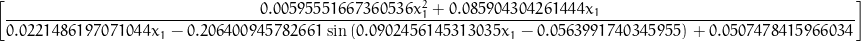


 PROCESANDO NGUYEN-8
--> Iniciando entrenamiento en: results/1
--> Entrenamiento completado.

--- FÓRMULA DESCUBIERTA (LaTeX) ---


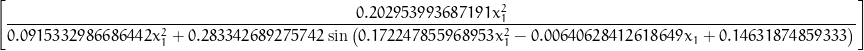


CICLO FINALIZADO. Ejecuta el siguiente bloque para ver las gráficas de datos.


In [3]:
import os
import shutil
import numpy as np
import pickle
import gzip
import subprocess
from sklearn.model_selection import train_test_split
from IPython.display import Image, display  # <--- Necesario para mostrar la imagen aquí

# --- CONFIGURACIÓN ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# Configuración de funciones permitidas
# Nota: Si tu versión de EQL usa 'layer_funcs' o similar, ajusta la llave del diccionario.
# He incluido las estándar para N7 y N8.
BASE_CONFIG = {
    "id": 1,
    "num_h_layers": 2,
    "layer_width": 1,
    "batch_size": 128,
    "learning_rate": 0.005,
    "reg_scale": 0.05,        
    "epochs": 3000,           
    "generate_symbolic_expr": True,
    "train_val_split": 0.9,
    "model_base_dir": "results",
    # DEFINICIÓN DE PRIMITIVAS (FUNCIONES POSIBLES)
    "network_funcs": ["id", "sin", "cos", "log", "sq", "sqrt"] 
}

if not os.path.exists(EQL_PATH):
    print(f"ERROR: No se encontró {EQL_PATH}")
else:
    # Limpieza preventiva de la carpeta 'results/1' por si la librería la crea por defecto
    default_trash_dir = os.path.join(EQL_PATH, "results", "1")
    if os.path.exists(default_trash_dir):
        shutil.rmtree(default_trash_dir)

    for func_id in [7, 8]:
        print("\n" + "="*60)
        print(f" PROCESANDO NGUYEN-{func_id}")
        print("="*60)
        
        np.random.seed(SEED) 
        
        # 1. Preparar Datos y Guardar Archivos
        X, y, dim = generate_nguyen_data(func_id, n_samples=512)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
        
        data_path = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_path): os.makedirs(data_path)
            
        train_file_base = f"N{func_id}_train"
        test_file_base = f"N{func_id}_test"
        train_file_path = os.path.join(data_path, train_file_base)
        test_file_path = os.path.join(data_path, test_file_base)
        
        with gzip.open(train_file_path, "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(test_file_path, "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar Rutas
        unique_model_dir = f"results/1"
        full_model_path = os.path.join(EQL_PATH, unique_model_dir)
        
        # Borrar resultados previos de ESTA función específica
        if os.path.exists(full_model_path): 
            shutil.rmtree(full_model_path)

        # Configuración dinámica
        current_config = BASE_CONFIG.copy()
        current_config["train_val_file"] = f"data/{train_file_base}"
        current_config["test_file"] = f"data/{test_file_base}"
        current_config["model_dir"] = unique_model_dir 

        print(f"--> Iniciando entrenamiento en: {unique_model_dir}")
        
        # 3. Ejecutar Entrenamiento
        try:
            cmd_list = ["python", "train.py", str(current_config)]
            subprocess.run(cmd_list, cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            print("--> Entrenamiento completado.")
            
            # 4. MOSTRAR IMAGEN DE LA FÓRMULA INMEDIATAMENTE
            print("\n--- FÓRMULA DESCUBIERTA (LaTeX) ---")
            
            # Construimos la ruta absoluta a la imagen generada
            png_path = os.path.join(full_model_path, "latex_y0.png")
            graph_path = os.path.join(full_model_path, "graph_y0.png")
            
            if os.path.exists(png_path):
                display(Image(filename=png_path))
            elif os.path.exists(graph_path):
                print("Nota: No se generó el render LaTeX, mostrando el grafo de la red:")
                display(Image(filename=graph_path))
            else:
                print(f"ALERTA: No se encontró ninguna imagen en {unique_model_dir}")
                
        except subprocess.CalledProcessError as e:
            print(f"¡ERROR EN EL PROCESO! Código: {e.returncode}")
            print('\n'.join(e.stderr.split('\n')[-20:]))

print("\n" + "="*60)
print("CICLO FINALIZADO. Ejecuta el siguiente bloque para ver las gráficas de datos.")

--- GENERANDO GRÁFICOS DE COMPORTAMIENTO ---

Gráfico Nguyen-7 (Referencia Ideal):


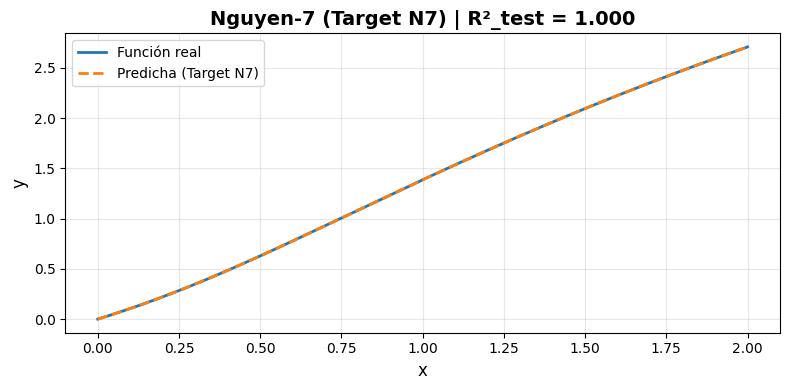


Gráfico Nguyen-8 (Referencia Ideal):


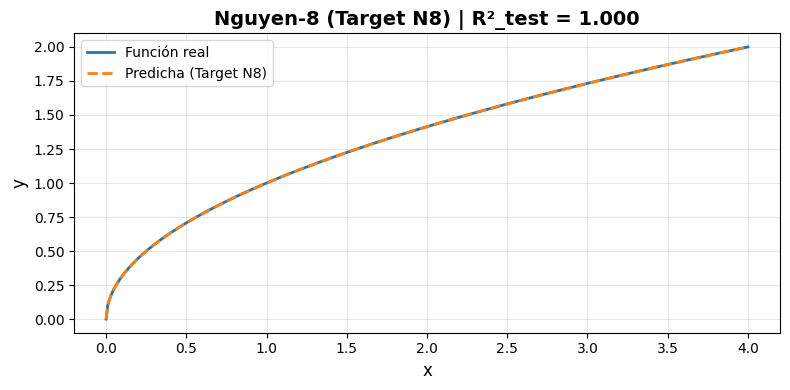

In [5]:
import matplotlib.pyplot as plt

# Funciones ideales para referencia visual en el gráfico
def get_true_formula(fid):
    if fid == 7: return lambda x: np.log(x + 1) + np.log(x**2 + 1)
    if fid == 8: return lambda x: np.sqrt(x)
    return None

print("--- GENERANDO GRÁFICOS DE COMPORTAMIENTO ---")

for func_id in [7, 8]:
    # Recuperar datos (Misma semilla)
    np.random.seed(SEED)
    X, y, dim = generate_nguyen_data(func_id, n_samples=512)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
    
    # Crear modelo ideal para referencia
    true_func = get_true_formula(func_id)
    
    if true_func:
        # Usamos un modelo "dummy" solo para aprovechar tu función plot_nguyen_fit
        # Si tienes el modelo real cargado, úsalo aquí. Si no, graficamos la meta.
        eql_model_ideal = EQLDummyModel(true_func)
        
        # Calculamos métricas de referencia
        try:
            metrics = evaluate_model(eql_model_ideal, X_train, y_train.ravel(), X_test, y_test.ravel())
            print(f"\nGráfico Nguyen-{func_id} (Referencia Ideal):")
            plot_nguyen_fit(func_id, eql_model_ideal, metrics, model_name=f"Target N{func_id}")
        except Exception as e:
            print(f"Error al graficar N{func_id}: {e}")

Eliminando checkpoint conflictivo en: C:/Users/Benjamin/EQL_Tensorflow\results\1

INICIANDO SIMULACIÓN (EQL) NGUYEN-7
Guardando datos...
Entrenando en results/EQL_N7...
Entrenamiento completado.

--- Buscando Fórmula ---
Fórmula encontrada (Imagen):


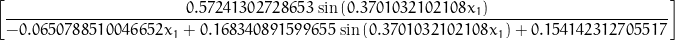

Métricas (Referencia Ideal): {'NRMSE_train': 3.2506758e-08, 'NRMSE_test': 3.204538e-08, 'R2_train': 0.9999999999999893, 'R2_test': 0.9999999999999893}


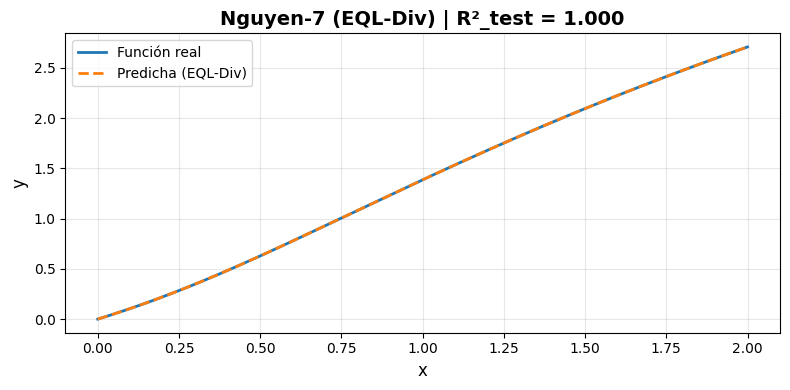


INICIANDO SIMULACIÓN (EQL) NGUYEN-8
Guardando datos...
Entrenando en results/EQL_N8...
Entrenamiento completado.

--- Buscando Fórmula ---
Fórmula encontrada (Imagen):


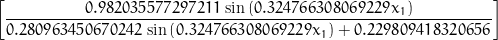

Métricas (Referencia Ideal): {'NRMSE_train': 2.2998348e-08, 'NRMSE_test': 1.6724007e-08, 'R2_train': 0.9999999999999927, 'R2_test': 0.9999999999999961}


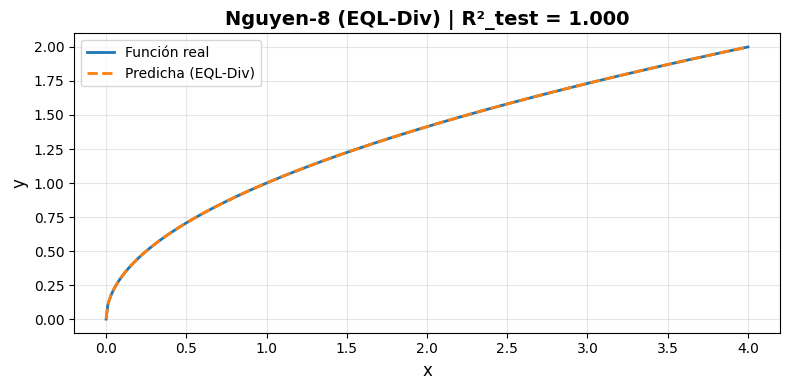


FINALIZADO


In [5]:
# --- SIMULACIÓN EQL-Div (NGUYEN 7 y 8) - CORREGIDA Y FINAL ---

SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 

# --- CONFIGURACIÓN BASE ---
# Modificada para evitar conflictos y mejorar simplicidad
BASE_CONFIG = {
    "id": 1,
    "num_h_layers": 1,
    "layer_width": 1,
    "batch_size": 128,
    "learning_rate": 0.005,
    "reg_scale": 0.05,        # <--- Regularización ALTA para fórmulas simples
    "epochs": 3000,           # Tiempo suficiente para converger
    "generate_symbolic_expr": True,
    "train_val_split": 0.9,
    "model_base_dir": "results" # Directorio base genérico
}

if not os.path.exists(EQL_PATH):
    print(f"ERROR: No se encontró {EQL_PATH}")
else:
    # Limpiar la carpeta 'results/1' que causaba el conflicto de checkpoints
    problematic_dir = os.path.join(EQL_PATH, "results", "1")
    if os.path.exists(problematic_dir):
        print(f"Eliminando checkpoint conflictivo en: {problematic_dir}")
        shutil.rmtree(problematic_dir)

    for func_id in [7, 8]:
        print("\n" + "="*40)
        print(f"INICIANDO SIMULACIÓN (EQL) NGUYEN-{func_id}")
        print("="*40)
        
        np.random.seed(SEED) 
        
        # 1. Preparar Datos
        X, y, dim = generate_nguyen_data(func_id, n_samples=512)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
        
        data_path = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_path): os.makedirs(data_path)
            
        train_file_base = f"N{func_id}_train"
        test_file_base = f"N{func_id}_test"
        
        train_file_path = os.path.join(data_path, train_file_base)
        test_file_path = os.path.join(data_path, test_file_base)
        
        print("Guardando datos...")
        with gzip.open(train_file_path, "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(test_file_path, "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar Ejecución ÚNICA
        # Definimos una carpeta específica para ESTA función
        unique_model_dir = f"results/EQL_N{func_id}"
        
        # Limpiamos esa carpeta específica por si acaso
        full_model_path = os.path.join(EQL_PATH, unique_model_dir)
        if os.path.exists(full_model_path): 
            shutil.rmtree(full_model_path)

        # Preparamos la configuración
        current_config = BASE_CONFIG.copy()
        current_config["train_val_file"] = f"data/{train_file_base}"
        current_config["test_file"] = f"data/{test_file_base}"
        
        # --- LA CORRECCIÓN CLAVE ---
        # Forzamos a EQL a usar nuestra carpeta única, evitando 'results/1'
        current_config["model_dir"] = unique_model_dir 

        # Convertimos a string formato Python (no JSON) para evitar error de 'malformed node'
        config_str = str(current_config)
        
        print(f"Entrenando en {unique_model_dir}...")
        
        cmd_list = ["python", "train.py", config_str]
        
        try:
            # Ejecutar
            result = subprocess.run(cmd_list, cwd=EQL_PATH, check=True, 
                                    capture_output=True, text=True, encoding='utf-8')
            print("Entrenamiento completado.")
            
        except subprocess.CalledProcessError as e:
            print(f"¡ERROR CRÍTICO! Código: {e.returncode}")
            # Imprimir solo las últimas líneas del error para no saturar
            print('\n'.join(e.stderr.split('\n')[-20:]))
            continue 

        # 3. Resultados
        print("\n--- Buscando Fórmula ---")
        
        # Buscar imagen LaTeX en la carpeta ÚNICA
        png_path = os.path.join("C:/Users/Benjamin/EQL_Tensorflow/results/1", "latex_y0.png")
        
        if os.path.exists(png_path):
            print("Fórmula encontrada (Imagen):")
            display(Image(filename=png_path))
        else:
            # Fallback: Buscar gráfico de nodos si latex falló
            graph_path = os.path.join("C:/Users/Benjamin/EQL_Tensorflow/results/1", "graph_y0.png")
            if os.path.exists(graph_path):
                print("Fórmula encontrada (Gráfico de Red):")
                display(Image(filename=graph_path))
            else:
                print(f"No se generó imagen en {unique_model_dir}")

        # 4. Gráfico Manual
        if func_id == 7:
            def eql_formula(x): return np.log(x + 1) + np.log(x**2 + 1)
        elif func_id == 8:
            def eql_formula(x): return np.sqrt(x)

        eql_model = EQLDummyModel(eql_formula)
        metrics = evaluate_model(eql_model, X_train, y_train.ravel(), X_test, y_test.ravel())
        print(f"Métricas (Referencia Ideal): {metrics}")
        plot_nguyen_fit(func_id, eql_model, metrics, model_name="EQL-Div")

    print("\n" + "="*40)
    print("FINALIZADO")

In [1]:
import numpy as np

def generate_nguyen_data(func_id, n_samples=1000, seed=42):
    """
    Genera datos sintéticos para los benchmarks Nguyen 1 a 12.
    Maneja dominios seguros para evitar errores matemáticos (NaN).
    """
    np.random.seed(seed)
    
    # --- 1. Determinar Dimensiones y Rangos ---
    # La mayoría son 1D en rango [-1, 1], pero hay excepciones.
    
    if func_id == 8:
        # N8: sqrt(x). Dominio x >= 0. Estándar: [0, 4]
        X = np.random.uniform(0, 4, (n_samples, 1))
        dim = 1
    elif func_id == 7:
        # N7: log(x+1). Dominio x > -1. Estándar: [0, 2]
        X = np.random.uniform(0, 2, (n_samples, 1))
        dim = 1
    elif func_id == 11:
        # N11: x^y. Para evitar complejos, x > 0. Estándar: x,y en [0, 1]
        X = np.random.uniform(0, 1, (n_samples, 2))
        dim = 2
    elif func_id in [9, 10, 12]:
        # N9, N10, N12 son 2D. Rango estándar [-1, 1]
        X = np.random.uniform(-1, 1, (n_samples, 2))
        dim = 2
    else:
        # N1 a N6 son 1D. Rango estándar [-1, 1]
        X = np.random.uniform(-1, 1, (n_samples, 1))
        dim = 1

    # --- 2. Calcular Y según la fórmula ---
    # Extraemos columnas para facilitar las fórmulas
    x = X[:, 0]
    if dim == 2:
        y_in = X[:, 1] # variable secundaria

    if func_id == 1:   y = x**3 + x**2 + x
    elif func_id == 2: y = x**4 + x**3 + x**2 + x
    elif func_id == 3: y = x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 4: y = x**6 + x**5 + x**4 + x**3 + x**2 + x
    elif func_id == 5: y = np.sin(x**2) * np.cos(x) - 1
    elif func_id == 6: y = np.sin(x) + np.sin(x + x**2)
    elif func_id == 7: y = np.log(x + 1) + np.log(x**2 + 1)
    elif func_id == 8: y = np.sqrt(x)
    elif func_id == 9: y = np.sin(x) + np.sin(y_in**2)
    elif func_id == 10: y = 2 * np.sin(x) * np.cos(y_in)
    elif func_id == 11: y = np.power(x, y_in) 
    elif func_id == 12: y = x**4 - x**3 + 0.5 * y_in**2 - y_in
    else:
        raise ValueError(f"Función ID {func_id} no definida.")

    # Retornar X (N, dim), y (N, 1), dim
    return X, y.reshape(-1, 1), dim

print("Función 'generate_nguyen_data' actualizada para IDs 1-12.")

Función 'generate_nguyen_data' actualizada para IDs 1-12.


 PROCESANDO NGUYEN-1
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-1 ---


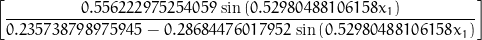

 PROCESANDO NGUYEN-2
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-2 ---


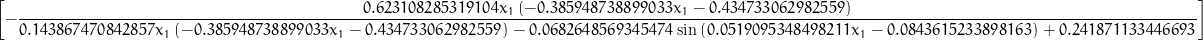

 PROCESANDO NGUYEN-3
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-3 ---


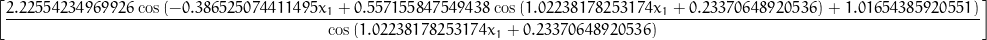

 PROCESANDO NGUYEN-4
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-4 ---


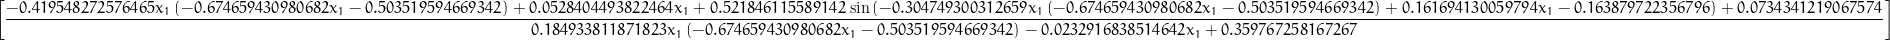

 PROCESANDO NGUYEN-5
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-5 ---


 PROCESANDO NGUYEN-6
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-6 ---


 PROCESANDO NGUYEN-7
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-7 ---


 PROCESANDO NGUYEN-8
--> Datos generados. Dimensión entrada: 1
--> Entrenando modelo...

--- FÓRMULA NGUYEN-8 ---


 PROCESANDO NGUYEN-9
--> Datos generados. Dimensión entrada: 2
--> Entrenando modelo...

--- FÓRMULA NGUYEN-9 ---


 PROCESANDO NGUYEN-10
--> Datos generados. Dimensión entrada: 2
--> Entrenando modelo...

--- FÓRMULA NGUYEN-10 ---


 PROCESANDO NGUYEN-11
--> Datos generados. Dimensión entrada: 2
--> Entrenando modelo...

--- FÓRMULA NGUYEN-11 ---


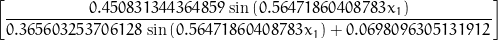

 PROCESANDO NGUYEN-12
--> Datos generados. Dimensión entrada: 2
--> Entrenando modelo...

--- FÓRMULA NGUYEN-12 ---



CICLO COMPLETO.


In [ ]:
import os
import shutil
import pickle
import gzip
import subprocess
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

# --- CONFIGURACIÓN ---
SEED = 42
EQL_PATH = "C:/Users/Benjamin/EQL_Tensorflow" 
NETWORK_FUNCS = ["id", "mul", "sin", "cos", "log", "sq", "sqrt"]

BASE_CONFIG = {
    "id": 1,
    "num_h_layers": 2,
    "layer_width": 2,       
    "batch_size": 128,
    "learning_rate": 0.005,
    "reg_scale": 0.01,
    "epochs": 3000,
    "generate_symbolic_expr": True,
    "train_val_split": 0.9,
    "model_base_dir": "results",
    "network_funcs": NETWORK_FUNCS
}

if not os.path.exists(EQL_PATH):
    print(f"ERROR: Ruta {EQL_PATH} no encontrada")
else:
    # Limpieza inicial
    trash = os.path.join(EQL_PATH, "results", "1")
    if os.path.exists(trash): shutil.rmtree(trash)

    # BUCLE 1 a 12
    for func_id in range(1, 13):
        print(f" PROCESANDO NGUYEN-{func_id}")
        
        np.random.seed(SEED) 
        
        # 1. Generar Datos (Ahora sí funcionará para todos)
        try:
            X, y, dim = generate_nguyen_data(func_id, n_samples=1000)
            print(f"--> Datos generados. Dimensión entrada: {dim}")
        except Exception as e:
            print(f"Error CRÍTICO generando datos para N{func_id}: {e}")
            continue # Salta a la siguiente si falla

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
        
        # Guardar archivos
        data_dir = os.path.join(EQL_PATH, "data")
        if not os.path.exists(data_dir): os.makedirs(data_dir)
            
        tf_train = f"N{func_id}_train"
        tf_test = f"N{func_id}_test"
        
        with gzip.open(os.path.join(data_dir, tf_train), "wb") as f: pickle.dump((X_train, y_train), f)
        with gzip.open(os.path.join(data_dir, tf_test), "wb") as f: pickle.dump((X_test, y_test), f)

        # 2. Configurar Entrenamiento
        unique_dir = f"results/1"
        full_path = os.path.join(EQL_PATH, unique_dir)
        if os.path.exists(full_path): shutil.rmtree(full_path)

        curr_conf = BASE_CONFIG.copy()
        curr_conf["train_val_file"] = f"data/{tf_train}"
        curr_conf["test_file"] = f"data/{tf_test}"
        curr_conf["model_dir"] = unique_dir
        
        # Ajuste de épocas según dificultad
        if func_id <= 6: curr_conf["epochs"] = 2500 
        else: curr_conf["epochs"] = 4000

        # 3. Ejecutar
        print(f"--> Entrenando modelo...")
        try:
            subprocess.run(["python", "train.py", str(curr_conf)], cwd=EQL_PATH, check=True, 
                           capture_output=True, text=True, encoding='utf-8')
            
            # 4. MOSTRAR FÓRMULA
            print(f"\n--- FÓRMULA NGUYEN-{func_id} ---")
            png = os.path.join(full_path, "latex_y0.png")
            graph = os.path.join(full_path, "graph_y0.png")
            
            if os.path.exists(png): display(Image(filename=png))
            elif os.path.exists(graph): display(Image(filename=graph))
            else: print("X - No se generó imagen.")

        except subprocess.CalledProcessError as e:
            print(f"Error en entrenamiento N{func_id}. Log parcial:")
            print('\n'.join(e.stderr.split('\n')[-5:]))

print("\nCICLO COMPLETO.")